# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [Fahira Zahra Fitria Rahma]
- **Email:** [CDCC002D6X1917@student.devacademy.id]
- **ID Dicoding:** [CDCC002D6X1917]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh musim terhadap rata-rata penyewaan sepedaa per hari selama tahun 2011-2012?
- **Pertanyaan 2:** Bagaimana tren total penyewaan sepeda per tahun dari 2011 hingga 2012, serta bagaimana pola rata-rata penyewaan sepeda per bulan pada periode tersebut?


## Import Semua Packages/Library yang Digunakan

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## Data Wrangling

### Gathering Data

#### Load df ...

In [4]:
day_df = pd.read_csv("/content/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
hour_df = pd.read_csv("/content/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Dataset sepeda terdiri dari dua jenis data, yaitu data harian dan data per jam, jadi kita bisa melihat pola penggunaan sepeda secara umum maupun lebih detail tiap jam.
- Adapun variabel pada dataset yaitu cuaca, suhu, kelembapan, dan musim, yang kemungkinan besar memengaruhi jumlah penyewaan sepeda.
- Jumlah penyewaan sepeda dibagi menjadi dua jenis pengguna, yaitu casual (pengguna biasa) dan registered (pengguna terdaftar), sehingga kita bisa membandingkan perilaku keduanya.
- Data mencakup periode tahun 2011 sampai 2012, sehingga bisa digunakan untuk melihat perubahan atau tren
- Adapun variabel yang akan dianalisis adalah jumlah total penyewaan sepeda, karena ini menunjukkan tingkat permintaan sepeda secara keseluruhan


### Assessing Data

**Day**

In [6]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [7]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [8]:
print('Jumlah Duplikasi: ', day_df.duplicated().sum())
day_df.describe()

Jumlah Duplikasi:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Hour**

In [9]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [10]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [11]:
print('Jumlah duplikasi: ', hour_df.duplicated().sum())
hour_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [12]:
print('Jumlah Duplikasi: ', day_df.duplicated().sum())
day_df.describe()

Jumlah Duplikasi:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Hasil dari pengecekan data tidak ada missing value di dataframe hour_df dan day_df, namun ada beberapa masalah lainya:
*   Kolom dteday masih dalam format string
*  Variabel temp, atemp, hum, dan windspeed masih dalam bentuk normalisasi
* Terdapat kolom yang tidak terlalu terlalu terpakai seperti kolom instant dan workingday karena sudah ada week day
*  Variabel kategorikal seperti season dan weathersit 'season', 'mnth', 'holiday', 'weekday', 'weathersit'masih dalam bentuk int
* beberapa kolom disingkat




**Steps to Take:**
- Kita akan mengubah kolom dteday menjadi tipe datetime agar dapat digunakan dalam analisis berbasis waktu
- Menginterpretasikan atau menyesuaikan variabel yang masih dalam bentuk normalisasi (temp, atemp, hum, windspeed) agar lebih mudah dipahami
- Menghapus kolom yang tidak terlalu terlalu terpakai seperti kolom instant dan workingday
- Mengubah menjadi variabel kategorikal seperti kolom 'season', 'mnth', 'holiday', 'weekday', 'weathersit' menjadi label yang lebih informatif
- rename nama kolom yr mnth (yang disingkat2)

### Cleaning Data

## rename

In [13]:
day_df.rename(columns={'yr':'year','mnth':'month', 'weathersit':'weather_situation', 'windspeed':'wind_speed','cnt':'count_cr','hum':'humidity'},inplace=True)
hour_df.rename(columns={'yr':'year','hr':'hours','mnth':'month', 'weathersit':'weather_situation','windspeed':'wind_speed','cnt':'count_cr','hum':'humidity'},inplace=True)

#### Mengubah Tipe Data dteday menjadi tipe datetime

In [14]:
#  Mengubah kolom dteday menjadi tipe datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

###Interpretasi data normalisasi

In [15]:
## day
day_df['temp_actual'] = day_df['temp'] * 41
day_df['atemp_actual'] = day_df['atemp'] * 50

# kelembapan (%)
day_df['hum_actual'] = day_df['humidity'] * 100

# windspeed
day_df['windspeed_actual'] = day_df['wind_speed'] * 67

In [16]:
## hour
hour_df['temp_actual'] = hour_df['temp'] * 41
hour_df['atemp_actual'] = hour_df['atemp'] * 50
hour_df['hum_actual'] = hour_df['humidity'] * 100
hour_df['windspeed_actual'] = hour_df['wind_speed'] * 67

#### menghapus kolom instant dan workingday menguunakan droping

In [17]:
hour_df.drop(['workingday'], axis = 1, inplace= True)
day_df.drop(['workingday'], axis = 1, inplace= True)

## Ubah variabel kategorikal jadi label

In [18]:
# season
day_df['season'].replace((1,2,3,4), ('Spring','Summer','Fall','Winter'), inplace=True)
hour_df['season'].replace((1,2,3,4), ('Spring','Summer','Fall','Winter'), inplace=True)

# month
day_df['month'].replace((1,2,3,4,5,6,7,8,9,10,11,12),
                       ('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'),
                       inplace=True)

hour_df['month'].replace((1,2,3,4,5,6,7,8,9,10,11,12),
                        ('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'),
                        inplace=True)

# weather_situation
day_df['weather_situation'].replace((1,2,3,4),
                            ('Clear','Mist','Light Rain/Snow','Heavy Rain/Snow'),
                            inplace=True)

hour_df['weather_situation'].replace((1,2,3,4),
                             ('Clear','Mist','Light Rain/Snow','Heavy Rain/Snow'),
                             inplace=True)

# weekday
day_df['weekday'].replace((0,1,2,3,4,5,6),
                         ('Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'),
                         inplace=True)

hour_df['weekday'].replace((0,1,2,3,4,5,6),
                          ('Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'),
                          inplace=True)

# holiday
day_df['holiday'].replace((0,1), ('No','Yes'), inplace=True)
hour_df['holiday'].replace((0,1), ('No','Yes'), inplace=True)

# year
day_df['year'].replace((0,1), ('2011','2012'), inplace=True)
hour_df['year'].replace((0,1), ('2011','2012'), inplace=True)

/tmp/ipykernel_899/2456938023.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  day_df['season'].replace((1,2,3,4), ('Spring','Summer','Fall','Winter'), inplace=True)
/tmp/ipykernel_899/2456938023.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

**Insight:** Pada tahap ini telah dilakukan
- Kolom instant dan workingday telah dihapus karena tidak memberikan informasi yang signifikan untuk analisis
- Kolom dteday telah dikonversi menjadi tipe datetime agar dapat digunakan dalam analisis berbasis waktu
- Variabel seperti season, mnth, holiday, weekday, dan weathersit telah diubah dari tipe integer menjadi kategori
- Nililai yang normal telah dikembalikan ke data asli untuk memperoleh informasi


## Exploratory Data Analysis (EDA)
## untuk insight aja kak (yang jadi pertanyaan business tetap 2)

### Explore Data hour_df


In [19]:
hour_df.describe(include="all")

,instant,dteday,season,year,month,hours,holiday,weekday,weather_situation,temp,atemp,humidity,wind_speed,casual,registered,count_cr,temp_actual,atemp_actual,hum_actual,windspeed_actual
count,17379.0000,17379,17379,17379,17379,17379.000000,17379,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,2,12,NaN,2,7,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,2012,Jul,NaN,No,Saturday,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,8734,1488,NaN,16879,2512,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,11.546752,NaN,NaN,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088,20.376474,23.788755,62.722884,12.736540
min,1.0000,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.820000,0.000000,0.000000,0.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000,13.940000,16.665000,48.000000,7.001500
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000,20.500000,24.240000,63.000000,12.998000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000,27.060000,31.060000,78.000000,16.997900
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,NaN,23.000000,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000,41.000000,50.000000,100.000000,56.996900


**Insight:** (Opsional)
- Berdasarkan tabel diatas,jumlah pelanggan sebanyak 17.379 mencakup periode tahun 2011-2012, sehingga cukup representatif untuk analisis pola penyewaan sepeda.
- Rata-rata jumlah penyewaan sepeda per jam adalah sekitar 189


In [20]:
hour_usage = hour_df.groupby('hours')['count_cr'].mean()
hour_usage

,count_cr
hours,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


In [21]:
## jam max & min
hour_usage.idxmax(), hour_usage.idxmin()

(np.int64(17), np.int64(4))

Berdasarkan hasil disatas, rata rata penyewaan sepeda tertinggi terjadi pada pukul 17.00, sedangkan jumlah terendah terjadi pada pukul 04.00. Hal ini menunjukkan bahwa aktivitas penyewaan sepeda meningkat pada sore hari, yang kemungkinan berkaitan dengan waktu pulang kerja (jika pada hari weekday), dan menurun pada dini hari kemungkinan karena tidur

### Explore Data day_df


In [46]:
day_df.describe(include="all")

,instant,dteday,season,year,month,holiday,weekday,weather_situation,temp,atemp,humidity,wind_speed,casual,registered,count_cr,temp_actual,atemp_actual,hum_actual,windspeed_actual,temp_category
count,731.000000,731,731,731,731,731,731,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731
unique,NaN,NaN,4,2,12,2,7,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,Fall,2012,Jan,No,Saturday,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Warm
freq,NaN,NaN,188,366,62,710,105,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300
mean,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837,20.310776,23.717699,62.789406,12.762576,NaN
min,1.000000,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000,2.424346,3.953480,0.000000,1.500244,NaN
25%,183.500000,2011-07-02 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000,13.820424,16.892125,52.000000,9.041650,NaN
50%,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000,20.431653,24.336650,62.666700,12.125325,NaN
75%,548.500000,2012-07-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000,26.872076,30.430100,73.020850,15.625371,NaN
max,731.000000,2012-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000,35.328347,42.044800,97.250000,34.000021,NaN


In [47]:
hour_df.to_csv("hour_clean.csv", index=False)
day_df.to_csv("day_clean.csv", index=False)

**Insight:** (Opsional)
- Berdasarkan tabel diatas,dataset terdiri dari 731 observasi yang mencakup periode tahun 2011 hingga 2012. Rata-rata jumlah penyewaan sepeda per hari adalah sekitar 4504 dengan variansi jumlah penyewaan yang cukup besar dilihat dari std nya yang menindikasikan ada pengaruh faktor eksternal seperti cuaca dan musim terhadap penyewaan sepeda sehingga selanjuynya akan diselidiki. Selain itu akan dilihat juga apakah terdapat tren pada penyewaan sepeda

In [23]:
# melihat jumlah penyewaan tiap season
season_usage = day_df.groupby('season')['count_cr'].mean().sort_values(ascending=False)
season_usage

,count_cr
season,
Fall,5644.303191
Summer,4992.331522
Winter,4728.162921
Spring,2604.132597


Berdasarkan tabel, rata-rata harian penyewaan sepeda tertinggi terjadi pada musim Fall, sedangkan terendah pada musim Spring. Hal ini kemungkinan dikarenakan Musim gugur cenderung memiliki kondisi cuaca yang lebih nyaman untuk bersepeda.

In [24]:
## melihat tren
year_usage = day_df.groupby('year')['count_cr'].sum()
year_usage

,count_cr
year,
2011,1243103
2012,2049576


In [49]:
# time series
time_series = day_df.groupby(['year','month'])['count_cr'].mean().reset_index()
time_series

,year,month,count_cr
0,2011,Apr,3162.333333
1,2011,Aug,4409.387097
2,2011,Dec,2816.870968
3,2011,Feb,1721.964286
4,2011,Jan,1231.903226
5,2011,Jul,4559.387097
6,2011,Jun,4783.733333
7,2011,Mar,2065.967742
8,2011,May,4381.322581
9,2011,Nov,3405.566667


Berdasarkan hasil diatas terjadi pertumbuhan pada  penggunaan sewa sepeda pada tahun 2012 terutama di bulan September pada tahun 2012

In [26]:
###  pengaruh cuaca terhadap penyewaan sepeda
day_df.groupby('weather_situation')['count_cr'].mean().sort_values(ascending=False)

,count_cr
weather_situation,
Clear,4876.786177
Mist,4035.862348
Light Rain/Snow,1803.285714


Berdasarkan hasil di atas, jumlah penyewaan tertinggiketika cuaca sedang cerah  dengan rata rata sekitar 4876, sedangkan pada cuaca hujan atau salju ringan terjadi penurunan penyewaan sepeda dengan rata-ratanya 1803 artinya kondisi cuaca memiliki pengaruh yang signifikan terhadap tingkat penyewaan sepeda

In [27]:
## pengaruh suhu
day_df['temp_category'] = pd.cut(day_df['temp_actual'],
                                bins=[0,10,20,30,50],
                                labels=['Cold','Cool','Warm','Hot'])

day_df.groupby('temp_category')['count_cr'].mean()

/tmp/ipykernel_899/3353085686.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby('temp_category')['count_cr'].mean()


,count_cr
temp_category,
Cold,1677.766667
Cool,3692.274247
Warm,5661.686667
Hot,5409.958333


Selanjutnya berdasarkan suhu juga, diperoleh bahwa rata-rata penyewaan pada suhu warm lebih tinggi sedangkan suhu cold paling rendah. Hal ini menunjukan bahwa suhu mempengaruhi penyewaan sepeda karena pelanggan akan mengutamakan kenyamanan dari lingkungan sekitar

In [28]:
## jumlah masing-masing pengguna casual dan registed
day_df[['casual','registered']].mean()

,0
casual,848.176471
registered,3656.172367


Berdasarkan hasil diatas, seseorang yang sudah menjadi member dengan belum menjadi member memiliki nilai yang cukup jauh. Sebagian besar pengguna adalah pelanggan tetap (registered), bukan pengguna sesekali

## Visualization & Explanatory Analysis

- **Pertanyaan 1:** Bagaimana pengaruh musim terhadap jumlah penyewaan sepeda (cnt) pada hari kerja selama tahun 2012?
- **Pertanyaan 2:** Bagaimana tren jumlah penyewaan sepeda (cnt) dari tahun 2011 hingga 2012, dan apakah terjadi peningkatan?

### Pertanyaan 1:

/tmp/ipykernel_899/3734926424.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


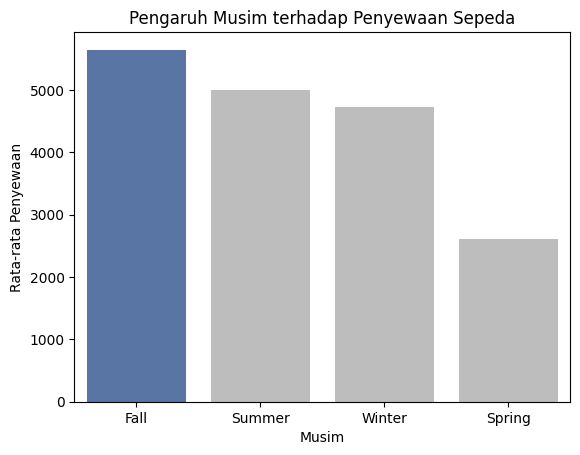

In [31]:
max_season = season_usage.idxmax()

colors = ['#4C72B0' if s == max_season else '#BDBDBD' for s in season_usage.index]

sns.barplot(
    x=season_usage.index,
    y=season_usage.values,
    palette=colors
)

plt.title("Pengaruh Musim terhadap Penyewaan Sepeda")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Penyewaan")

plt.show()

Berdasarkan grafik di atas, rata-rata penyewaan sepeda tertinggi terjadi pada musim Fall sebesar 5644 penyewaan, sedangkan terendah pada musim Spring sebesar 2604. Hal ini kemungkinan dikarenakan Musim gugur cenderung memiliki kondisi cuaca yang lebih nyaman untuk bersepeda dibandingkan spring yang kemungkinan disebabkan oleh kondisi cuaca yang masih tidak menentu atau belum optimal untuk aktivitas luar ruangan.

pertanyaan 2

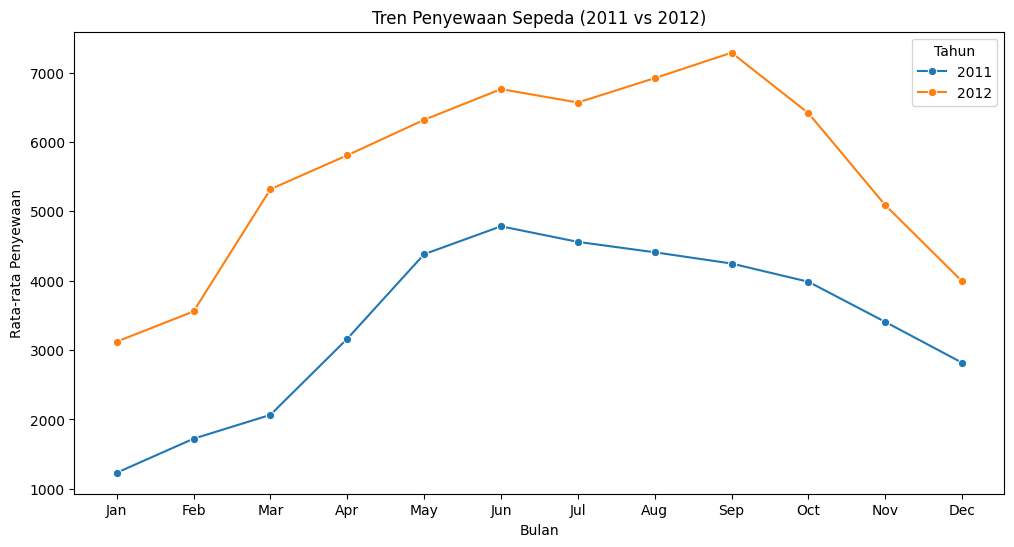

In [32]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

time_series['month'] = pd.Categorical(time_series['month'], categories=month_order, ordered=True)

time_series = time_series.sort_values(['year','month'])
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.lineplot(
    data=time_series,
    x='month',
    y='count_cr',
    hue='year',
    marker='o'
)

plt.title('Tren Penyewaan Sepeda (2011 vs 2012)')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Penyewaan')

plt.legend(title='Tahun')
plt.show()

Berdasarkan grafik, penyewaan sepeda pada tahun 2012 lebih tinggi dibandingkan 2011 di semua bulan. Selain itu, terdapat pola musiman dengan puncak penyewaan pada pertengahan tahun (Juni-September) dan penurunan di awal serta akhir tahun.

## Analisis Lanjutan (Opsional)

## Clustering berdasarkan waktu

In [44]:
hour_df['time_group'] = hour_df['hours'].apply(lambda x:
    'Morning' if 6 <= x < 12 else
    'Afternoon' if 12 <= x < 17 else
    'Evening' if 17 <= x < 21 else
    'Night'
)

time_cluster = hour_df.groupby('time_group')['count_cr'].mean().sort_values(ascending=False)
time_cluster

,count_cr
time_group,
Evening,356.201441
Afternoon,262.244719
Morning,208.100688
Night,60.604799


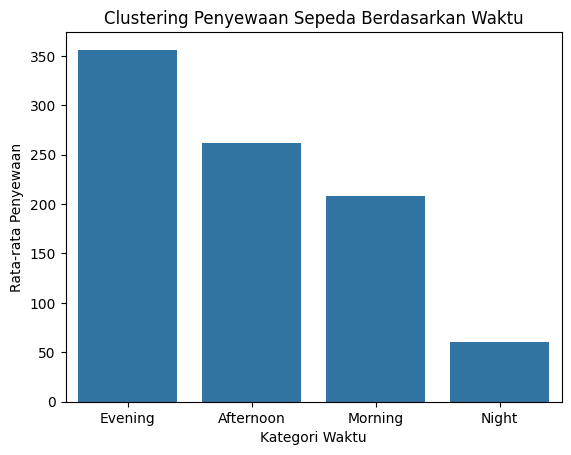

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=time_cluster.index, y=time_cluster.values)

plt.title("Clustering Penyewaan Sepeda Berdasarkan Waktu")
plt.xlabel("Kategori Waktu")
plt.ylabel("Rata-rata Penyewaan")

plt.show()

Berdasarkan hasil clustering waktu, terlihat bahwa rata-rata penyewaan sepeda tertinggi terjadi pada kelompok waktu evening sebesar 356 dan yang paling rendah malam yaitu sebesar 60. Hal ini kemungkinan disebabkan oleh aktivitas masyarakat seperti pulang kerja atau beraktivitas di luar ruangan. Sebaliknya, pada malam hingga dini hari, jumlah penyewaan sangat rendah karena minimnya aktivitas masyarakat pada waktu tersebut.

Analisis Tren Penyewaan Sepeda Berdasarkan Waktu

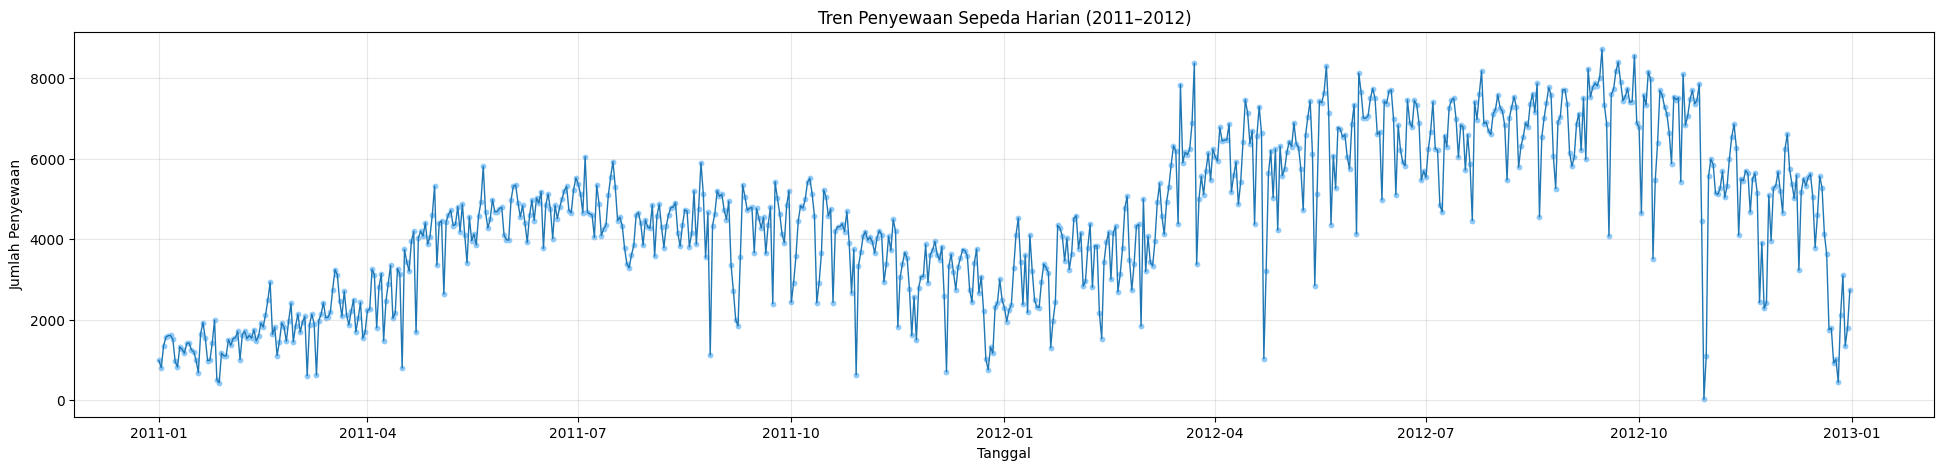

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

# Pastikan kolom tanggal sudah dalam format datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

# Membuat figure dengan ukuran lebar
plt.figure(figsize=(24, 5))

# Menghitung jumlah penyewaan sepeda per hari (menggunakan nilai maksimum harian)
daily_usage = day_df.groupby('dteday')['count_cr'].max()

# Membuat scatter plot
plt.scatter(daily_usage.index, daily_usage.values,
            color="#90CAF9", s=10, marker='o', label='Data Harian')

# Membuat line plot untuk melihat tren
plt.plot(daily_usage.index, daily_usage.values,
         color="#1f77b4", linewidth=1)

# Label sumbu
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penyewaan')

# Judul
plt.title('Tren Penyewaan Sepeda Harian (2011–2012)')

# Grid biar lebih jelas
plt.grid(alpha=0.3)

plt.show()

Berdasarkan hasil di atas, kita dapat melihat bahwa jumlah penyewaan terbanyak terjadi pada bulan September 2012. Selain itu, kita juga dapat melihat adanya penurunan jumlah order yang cukup signifikan pada bulan November menuju Deember 2012.

## Conclusion & Recommendation

Pertanyaan
- Pertanyaan 1: Pada jam berapa terjadi rata-rata penyewaan sepeda tertinggi dan terendah selama periode 2011-2012?
- Pertanyaan 2: Bagaimana pengaruh musim terhadap jumlah penyewaan sepeda (cnt) pada hari kerja selama tahun 2012?
- Pertanyaan 3: Bagaimana tren jumlah penyewaan sepeda (cnt) dari tahun 2011 hingga 2012, dan apakah terjadi peningkatan?

Conclution

- **Coculution Pertanyaan 1:** Berdasarkan hasil analisis, musim memiliki pengaruh terhadap rata-rata penyewaan sepeda perhari. Penyewaan sepeda tertinggi terjadi pada musim Fall, diikuti oleh Summer dan Winter, sedangkan yang terendah terjadi pada musim Spring. Hal ini disebabkan kondisi cuaca yang lebih nyaman dan stabil mendorong peningkatan penggunaan sepeda.
- **Conclution Pertanyaan 2:** Berdasarkan hasil analisis tren, terlihat total penyewaan perhari sepeda pada tahun 2012 secara konsisten lebih tinggi dibandingkan tahun 2011 di setiap bulan. Selain itu, terdapat pola musiman yang sama pada kedua tahun, yaitu peningkatan pada pertengahan tahun dan penurunan pada awal serta akhir tahun.
- analisis lanjutan : Berdasarkan hasil analisis clustering waktu, terlihat bahwa penyewaan sepeda tertinggi terjadi pada kelompok waktu Evening, diikuti Afternoon, Morning, dan terakhir night.Hal ini memperkuat bahwa penggunaan sepeda didominasi pada jam sibuk, khususnya sore hari. Selain itu bulan terbanyak  penyewaan terbanyak terjadi pada bulan September.

**Rekomendasi Action Item:**


- Meningkatkan ketersediaan sepeda pada musim dengan permintaan tinggi, seperti Fall dan Summer, untuk memaksimalkan penggunaan layanan.

- Manfaatkan pola tren (dari tahun 2011-2012) untuk perencanaan kapasitas, dengan menambah sepeda atau layanan pada tahun-tahun dengan pertumbuhan permintaan yang meningkat (seperti 2012).
